# HIICNN — Hybrid Image-Improving and CNN Stacking Ensemble for Traffic Sign Recognition


## Imports


In [1]:
import os
import time
import json

import numpy as np
import pandas as pd
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms, models

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

import matplotlib.pyplot as plt
%matplotlib inline

from tqdm.auto import tqdm

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


c:\Users\Mohammed Elidrissi\Desktop\traffic-sign-recognition-using-CNN\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU


## Configuration

In [ ]:
# ---------------------------------------------------------------------------
# Paths — assumes this notebook lives at the project root, next to your
# already-downloaded data/ folder (Train/, Test/, Train.csv, Test.csv).
# ---------------------------------------------------------------------------
PROJECT_ROOT = os.getcwd()
DATA_ROOT = os.path.join(PROJECT_ROOT, "data")
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints_improved-all_25_epochs")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results_improved-all_25_epochs")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# Device
# ---------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------------------------
# Dataset
# ---------------------------------------------------------------------------
NUM_CLASSES = 43
IMAGE_SIZE = 112          
VAL_SPLIT = 0.1           
                        
SEED = 42

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

USE_WEIGHTED_SAMPLER = True  

# ---------------------------------------------------------------------------
# Image enhancement stage
# ---------------------------------------------------------------------------
USE_SHARPENING = True
USE_UNSHARP_MASK = True
USE_CLAHE_CONTRAST = True

# ---------------------------------------------------------------------------
# Backbones used in the stacking ensemble
# ---------------------------------------------------------------------------
BACKBONES = ["resnet50", "vgg16", "efficientnet_b0"]

FINE_TUNE_LAST_BLOCK = True

# ---------------------------------------------------------------------------
# Global training defaults
# ---------------------------------------------------------------------------
BATCH_SIZE = 64
NUM_EPOCHS = 20
HEAD_LR = 1e-3
BACKBONE_LR = 1e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
NUM_WORKERS = 0
EARLY_STOP_PATIENCE = 5
USE_AMP = torch.cuda.is_available()   
# ---------------------------------------------------------------------------
# Per-model hyperparameters.
# ---------------------------------------------------------------------------
PER_MODEL_CONFIG = {
    "resnet50": {
        "epochs": 25,
        "head_lr": 1e-3,
        "backbone_lr": 1e-5,
        "early_stop_patience": 5,
        "unfreeze_depth": 1,    
    },
    "vgg16": {
        "epochs": 25,
        "head_lr": 1e-3,
        "backbone_lr": 1e-5,
        "early_stop_patience": 5,
        "unfreeze_depth": 1,    
    },
    "efficientnet_b0": {
        "epochs": 25,            
        "head_lr": 1e-3,
        "backbone_lr": 3e-5,    
        "early_stop_patience": 10,
        "unfreeze_depth": 3,    
    },
}

# ---------------------------------------------------------------------------
# Meta-learner (stacking head)
# ---------------------------------------------------------------------------
META_HIDDEN_DIM = 128
META_EPOCHS = 200
META_BATCH_SIZE = 128
META_LR = 3e-4
META_WEIGHT_DECAY = 1e-3
META_VAL_FRACTION = 0.2    

# ---------------------------------------------------------------------------
# Real-time framing
# ---------------------------------------------------------------------------
USE_AMP_INFERENCE = torch.cuda.is_available()
FAST_ENSEMBLE_BACKBONES = ["resnet50", "vgg16"]

print(f"Using device: {DEVICE}")


Using device: cuda


## 1. Image Enhancement Stage

In [3]:
def apply_clahe_contrast(img, clip_limit=2.0, tile_grid_size=(8, 8)):
    """Contrast Limited Adaptive Histogram Equalization on the L channel of LAB space."""
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_eq = clahe.apply(l)
    lab_eq = cv2.merge((l_eq, a, b))
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)


def apply_unsharp_mask(img, sigma=1.0, amount=1.5, threshold=0):
    """Classic unsharp masking: sharpened = original + amount * (original - blurred)."""
    blurred = cv2.GaussianBlur(img, (0, 0), sigma)
    sharpened = cv2.addWeighted(img, 1 + amount, blurred, -amount, 0)
    if threshold > 0:
        low_contrast_mask = np.abs(img.astype(int) - blurred.astype(int)) < threshold
        sharpened = np.where(low_contrast_mask, img, sharpened)
    return np.clip(sharpened, 0, 255).astype(np.uint8)


def apply_sharpening_kernel(img):
    """Edge-emphasizing 3x3 sharpening convolution kernel."""
    kernel = np.array([[0, -1, 0],
                        [-1, 5, -1],
                        [0, -1, 0]], dtype=np.float32)
    sharpened = cv2.filter2D(img, -1, kernel)
    return np.clip(sharpened, 0, 255).astype(np.uint8)


def enhance_image(img):
    """Full classical enhancement pipeline applied to a single RGB uint8 image."""
    out = img
    if USE_CLAHE_CONTRAST:
        out = apply_clahe_contrast(out)
    if USE_UNSHARP_MASK:
        out = apply_unsharp_mask(out)
    if USE_SHARPENING:
        out = apply_sharpening_kernel(out)
    return out


class EnhancementTransform:
    """Torchvision-compatible transform: PIL.Image -> enhanced PIL.Image."""

    def __call__(self, pil_img):
        arr = np.array(pil_img.convert("RGB"))
        enhanced = enhance_image(arr)
        return Image.fromarray(enhanced)


## 2. Dataset (Kaggle GTSRB CSV layout)


In [ ]:
def _find_csv_columns(df):
    """Kaggle GTSRB CSVs consistently use
    Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path — tolerant of
    minor casing differences across mirrors."""
    cols = {c.lower(): c for c in df.columns}
    for required in ("path", "classid"):
        if required not in cols:
            raise ValueError(f"Expected a '{required}' column in the GTSRB csv, got columns: {list(df.columns)}")
    roi_names = ["roi.x1", "roi.y1", "roi.x2", "roi.y2"]
    roi_cols = [cols[r] for r in roi_names] if all(r in cols for r in roi_names) else None
    return cols["path"], cols["classid"], roi_cols


class GTSRBCSVDataset(Dataset):
    """Reads Train.csv or Test.csv and loads the corresponding images
    from disk, cropping to the annotated ROI when the columns are present."""

    def __init__(self, root, csv_name, transform=None):
        self.root = root
        self.transform = transform
        csv_path = os.path.join(root, csv_name)
        if not os.path.exists(csv_path):
            raise FileNotFoundError(
                f"Could not find {csv_path}.\n"
                f"Expected the Kaggle GTSRB layout under DATA_ROOT ({root}):\n"
                f"  Train.csv, Test.csv, Train/<classid>/*.png, Test/*.png"
            )
        df = pd.read_csv(csv_path)
        self.path_col, self.class_col, self.roi_cols = _find_csv_columns(df)
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root, row[self.path_col])
        img = Image.open(img_path).convert("RGB")
        if self.roi_cols is not None:
            x1, y1, x2, y2 = (int(row[c]) for c in self.roi_cols)
            img = img.crop((x1, y1, x2, y2))
        label = int(row[self.class_col])
        if self.transform is not None:
            img = self.transform(img)
        return img, label


def build_transforms(train=True):
    ops = [EnhancementTransform()]
    if train:
        ops += [
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
        ]
    ops += [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
    return transforms.Compose(ops)


def get_datasets():
    """Returns (train_ds, val_ds, test_ds). val_ds is carved out of
    Train.csv (not augmented) and is used both to monitor backbone
    training and to generate the meta-learner's training data."""
    train_tf = build_transforms(train=True)
    eval_tf = build_transforms(train=False)

    full_train_aug = GTSRBCSVDataset(DATA_ROOT, "Train.csv", transform=train_tf)
    full_train_eval = GTSRBCSVDataset(DATA_ROOT, "Train.csv", transform=eval_tf)

    n_total = len(full_train_aug)
    n_val = int(n_total * VAL_SPLIT)
    n_train = n_total - n_val

    generator = torch.Generator().manual_seed(SEED)
    train_subset, val_subset_idx = random_split(full_train_aug, [n_train, n_val], generator=generator)
    val_indices = val_subset_idx.indices
    val_subset = Subset(full_train_eval, val_indices)

    test_ds = GTSRBCSVDataset(DATA_ROOT, "Test.csv", transform=eval_tf)
    return train_subset, val_subset, test_ds


def get_dataloaders():
    train_ds, val_ds, test_ds = get_datasets()
    pin = DEVICE.type == "cuda"

    if USE_WEIGHTED_SAMPLER:
        base_ds = train_ds.dataset  
        subset_labels = base_ds.df[base_ds.class_col].values[train_ds.indices]
        class_counts = np.bincount(subset_labels, minlength=NUM_CLASSES)
        class_weights = 1.0 / np.clip(class_counts, 1, None)
        sample_weights = class_weights[subset_labels]
        sampler = torch.utils.data.WeightedRandomSampler(
            weights=torch.as_tensor(sample_weights, dtype=torch.double),
            num_samples=len(sample_weights),
            replacement=True,
        )
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                                   num_workers=NUM_WORKERS, pin_memory=pin)
    else:
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                                   num_workers=NUM_WORKERS, pin_memory=pin)

    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)
    return train_loader, val_loader, test_loader


### Sanity check: raw vs. enhanced sample image


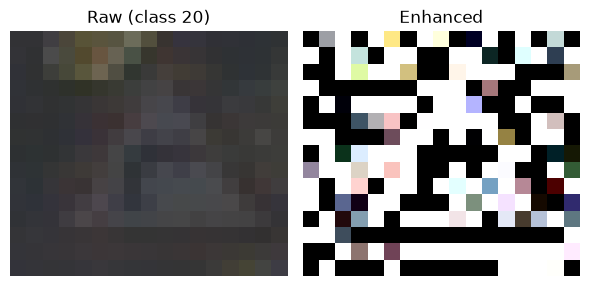

In [5]:
_demo_ds = GTSRBCSVDataset(DATA_ROOT, "Train.csv", transform=None)
_raw_img, _label = _demo_ds[0]
_enhanced_img = EnhancementTransform()(_raw_img)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(_raw_img); axes[0].set_title(f"Raw (class {_label})"); axes[0].axis("off")
axes[1].imshow(_enhanced_img); axes[1].set_title("Enhanced"); axes[1].axis("off")
plt.tight_layout()
plt.show()


## 3. Base models (ResNet50, VGG16, EfficientNetB0) + stacking meta-learner


In [ ]:
def _freeze(module):
    for p in module.parameters():
        p.requires_grad = False


def _unfreeze(module):
    for p in module.parameters():
        p.requires_grad = True


def build_resnet50(num_classes=NUM_CLASSES, fine_tune_last_block=FINE_TUNE_LAST_BLOCK, unfreeze_depth=1):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    _freeze(model)
    if fine_tune_last_block:
        stages = [model.layer4, model.layer3]
        for stage in stages[:unfreeze_depth]:
            _unfreeze(stage)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )
    return model  


def build_vgg16(num_classes=NUM_CLASSES, fine_tune_last_block=FINE_TUNE_LAST_BLOCK, unfreeze_depth=1):
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    _freeze(model.features)
    if fine_tune_last_block:
        # depth 1: conv5_x only (default, features[24:]).
        # depth 2: conv4_x+conv5_x (features[17:]) if a config asks for more.
        start_idx = {1: 24, 2: 17}.get(unfreeze_depth, 24)
        _unfreeze(model.features[start_idx:])
    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )
    return model


def build_efficientnet_b0(num_classes=NUM_CLASSES, fine_tune_last_block=FINE_TUNE_LAST_BLOCK, unfreeze_depth=3):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    _freeze(model.features)
    if fine_tune_last_block:
        n_unfreeze = {1: 2, 2: 2, 3: 4}.get(unfreeze_depth, 4)
        _unfreeze(model.features[-n_unfreeze:])
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )
    return model


BACKBONE_BUILDERS = {
    "resnet50": build_resnet50,
    "vgg16": build_vgg16,
    "efficientnet_b0": build_efficientnet_b0,
}

HEAD_ATTR = {
    "resnet50": "fc",
    "vgg16": "classifier",
    "efficientnet_b0": "classifier",
}


def build_backbone(name, num_classes=NUM_CLASSES, fine_tune_last_block=FINE_TUNE_LAST_BLOCK, unfreeze_depth=None):
    if name not in BACKBONE_BUILDERS:
        raise ValueError(f"Unknown backbone '{name}'. Options: {list(BACKBONE_BUILDERS)}")
    if unfreeze_depth is None:
        unfreeze_depth = PER_MODEL_CONFIG.get(name, {}).get("unfreeze_depth", 1)
    return BACKBONE_BUILDERS[name](num_classes=num_classes, fine_tune_last_block=fine_tune_last_block,
                                    unfreeze_depth=unfreeze_depth)


def get_param_groups(model, name, head_lr=None, backbone_lr=None):
    """Head params train at head_lr; any unfrozen backbone params train at
    the much smaller backbone_lr. Frozen params are excluded entirely.
    Falls back to the global HEAD_LR/BACKBONE_LR if no per-model value is
    given, so this stays backward compatible."""
    cfg = PER_MODEL_CONFIG.get(name, {})
    head_lr = head_lr if head_lr is not None else cfg.get("head_lr", HEAD_LR)
    backbone_lr = backbone_lr if backbone_lr is not None else cfg.get("backbone_lr", BACKBONE_LR)

    head_module = getattr(model, HEAD_ATTR[name])
    head_param_ids = set(id(p) for p in head_module.parameters())
    head, backbone = [], []
    for p in model.parameters():
        if not p.requires_grad:
            continue
        (head if id(p) in head_param_ids else backbone).append(p)
    groups = [{"params": head, "lr": head_lr}]
    if backbone:
        groups.append({"params": backbone, "lr": backbone_lr})
    return groups


class MetaLearner(nn.Module):
    """Small MLP stacking head: takes the concatenated softmax outputs of
    all base models and learns to weight/combine them into the final
    43-class prediction."""

    def __init__(self, num_backbones=len(BACKBONES), num_classes=NUM_CLASSES, hidden_dim=META_HIDDEN_DIM):
        super().__init__()
        in_dim = num_backbones * num_classes
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, x):
        return self.net(x)


## 4. Training functions


In [ ]:
def train_one_backbone(name, train_loader, val_loader):
    cfg = PER_MODEL_CONFIG.get(name, {})
    num_epochs = cfg.get("epochs", NUM_EPOCHS)
    patience = cfg.get("early_stop_patience", EARLY_STOP_PATIENCE)
    head_lr = cfg.get("head_lr", HEAD_LR)
    backbone_lr = cfg.get("backbone_lr", BACKBONE_LR)

    print(f"\n{'='*60}\nTraining backbone: {name}\n"
          f"  epochs={num_epochs}  head_lr={head_lr}  backbone_lr={backbone_lr}  "
          f"early_stop_patience={patience}\n{'='*60}")
    model = build_backbone(name).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

    param_groups = get_param_groups(model, name, head_lr=head_lr, backbone_lr=backbone_lr)
    optimizer = optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    best_val_acc = 0.0
    epochs_without_improvement = 0
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"{name}.pt")

    for epoch in range(num_epochs):
        model.train()
        running_loss, running_correct, n = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"[{name}] epoch {epoch+1}/{num_epochs}")
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * imgs.size(0)
            running_correct += (outputs.argmax(1) == labels).sum().item()
            n += imgs.size(0)
            pbar.set_postfix(loss=running_loss / n, acc=running_correct / n)

        val_acc = evaluate_accuracy(model, val_loader)
        scheduler.step(val_acc)
        print(f"[{name}] epoch {epoch+1}: train_acc={running_correct/n:.4f}  val_acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_without_improvement = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"  -> new best ({val_acc:.4f}), saved to {ckpt_path}")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"  -> no improvement for {patience} epochs, stopping early.")
                break

    print(f"Finished {name}. Best val acc: {best_val_acc:.4f}")
    return ckpt_path


@torch.no_grad()
def evaluate_accuracy(model, loader):
    model.eval()
    correct, n = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        correct += (outputs.argmax(1) == labels).sum().item()
        n += imgs.size(0)
    return correct / n


@torch.no_grad()
def get_softmax_predictions(model, loader):
    """Runs a backbone over a loader and returns (probs, labels) as numpy arrays."""
    model.eval()
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)


def train_meta_learner(val_loader, backbone_names=None):
    backbone_names = backbone_names or BACKBONES
    ckpt_name = "meta_learner.pt" if backbone_names == BACKBONES else "meta_learner_fast.pt"

    print(f"\n{'='*60}\nTraining stacking meta-learner over {backbone_names}\n{'='*60}")
    backbone_probs = []
    labels = None
    for name in backbone_names:
        model = build_backbone(name).to(DEVICE)
        model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, f"{name}.pt"), map_location=DEVICE))
        probs, lbls = get_softmax_predictions(model, val_loader)
        backbone_probs.append(probs)
        labels = lbls

    stacked_features = np.concatenate(backbone_probs, axis=1)

    n_total = len(labels)
    rng = np.random.default_rng(SEED)
    idx = rng.permutation(n_total)
    n_meta_val = int(n_total * META_VAL_FRACTION)
    val_idx, train_idx = idx[:n_meta_val], idx[n_meta_val:]

    X_train = torch.tensor(stacked_features[train_idx], dtype=torch.float32)
    y_train = torch.tensor(labels[train_idx], dtype=torch.long)
    X_val = torch.tensor(stacked_features[val_idx], dtype=torch.float32).to(DEVICE)
    y_val = torch.tensor(labels[val_idx], dtype=torch.long).to(DEVICE)

    meta_train_ds = torch.utils.data.TensorDataset(X_train, y_train)
    meta_train_loader = DataLoader(meta_train_ds, batch_size=META_BATCH_SIZE, shuffle=True)

    meta = MetaLearner(num_backbones=len(backbone_names)).to(DEVICE)
    optimizer = optim.AdamW(meta.parameters(), lr=META_LR, weight_decay=META_WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=META_EPOCHS)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

    best_val_acc = 0.0
    ckpt_path = os.path.join(CHECKPOINT_DIR, ckpt_name)

    for epoch in range(META_EPOCHS):
        meta.train()
        last_loss = None
        for xb, yb in meta_train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = meta(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            last_loss = loss.item()
        scheduler.step()

        meta.eval()
        with torch.no_grad():
            val_out = meta(X_val)
            val_acc = (val_out.argmax(1) == y_val).float().mean().item()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(meta.state_dict(), ckpt_path)

        if (epoch + 1) % 10 == 0:
            print(f"  meta epoch {epoch+1}/{META_EPOCHS}  loss={last_loss:.4f}  "
                  f"meta_val_acc={val_acc:.4f}  best={best_val_acc:.4f}")

    print(f"Meta-learner saved to {ckpt_path} (best meta-val acc: {best_val_acc:.4f})")


## Run: build the dataloaders


In [8]:
train_loader, val_loader, test_loader = get_dataloaders()
print(f"train: {len(train_loader.dataset)}  val: {len(val_loader.dataset)}  test: {len(test_loader.dataset)}")


train: 35289  val: 3920  test: 12630


## Run: train all three backbones

This is the slow step. With a GPU this takes a while depending on
`NUM_EPOCHS`; on CPU it will be very slow — reduce `NUM_EPOCHS` in the
config cell above for a quick smoke test first.


In [9]:
for _name in BACKBONES:
    train_one_backbone(_name, train_loader, val_loader)



Training backbone: resnet50
  epochs=25  head_lr=0.001  backbone_lr=1e-05  early_stop_patience=5


C:\Users\Mohammed Elidrissi\AppData\Local\Temp\ipykernel_3036\1623066807.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
[resnet50] epoch 1/25: 100%|██████████| 552/552 [01:34<00:00,  5.81it/s, acc=0.383, loss=2.27]


[resnet50] epoch 1: train_acc=0.3832  val_acc=0.5352
  -> new best (0.5352), saved to c:\Users\Mohammed Elidrissi\Desktop\traffic-sign-recognition-using-CNN\checkpoints_improved-v3\resnet50.pt


[resnet50] epoch 2/25: 100%|██████████| 552/552 [01:44<00:00,  5.28it/s, acc=0.581, loss=1.63]


[resnet50] epoch 2: train_acc=0.5809  val_acc=0.6332
  -> new best (0.6332), saved to c:\Users\Mohammed Elidrissi\Desktop\traffic-sign-recognition-using-CNN\checkpoints_improved-v3\resnet50.pt


...

[efficientnet_b0] epoch 23: train_acc=0.9799  val_acc=0.9694


[efficientnet_b0] epoch 24/25: 100%|██████████| 552/552 [01:35<00:00,  5.78it/s, acc=0.979, loss=0.487]


[efficientnet_b0] epoch 24: train_acc=0.9791  val_acc=0.9730
  -> new best (0.9730), saved to c:\Users\Mohammed Elidrissi\Desktop\traffic-sign-recognition-using-CNN\checkpoints_improved-v3\efficientnet_b0.pt


[efficientnet_b0] epoch 25/25: 100%|██████████| 552/552 [01:43<00:00,  5.34it/s, acc=0.981, loss=0.484]


[efficientnet_b0] epoch 25: train_acc=0.9813  val_acc=0.9758
  -> new best (0.9758), saved to c:\Users\Mohammed Elidrissi\Desktop\traffic-sign-recognition-using-CNN\checkpoints_improved-v3\efficientnet_b0.pt
Finished efficientnet_b0. Best val acc: 0.9758


## Run: train the stacking meta-learner


In [10]:
train_meta_learner(val_loader)                           # full 3-backbone stacking ensemble
train_meta_learner(val_loader, FAST_ENSEMBLE_BACKBONES)  # fast 2-backbone ensemble for real-time comparison


Training stacking meta-learner over ['resnet50', 'vgg16', 'efficientnet_b0']
  meta epoch 10/200  loss=0.7520  meta_val_acc=0.9656  best=0.9656
  meta epoch 20/200  loss=0.5700  meta_val_acc=0.9783  best=0.9783
  meta epoch 30/200  loss=0.5456  meta_val_acc=0.9770  best=0.9783
  meta epoch 40/200  loss=0.4739  meta_val_acc=0.9758  best=0.9783
  meta epoch 50/200  loss=0.5040  meta_val_acc=0.9770  best=0.9783
  meta epoch 60/200  loss=0.5286  meta_val_acc=0.9770  best=0.9783
  meta epoch 70/200  loss=0.4815  meta_val_acc=0.9770  best=0.9783
  meta epoch 80/200  loss=0.5033  meta_val_acc=0.9745  best=0.9783
  meta epoch 90/200  loss=0.4723  meta_val_acc=0.9732  best=0.9783
  meta epoch 100/200  loss=0.4792  meta_val_acc=0.9745  best=0.9783
  meta epoch 110/200  loss=0.4496  meta_val_acc=0.9732  best=0.9783
  meta epoch 120/200  loss=0.4635  meta_val_acc=0.9732  best=0.9783
  meta epoch 130/200  loss=0.4851  meta_val_acc=0.9732  best=0.9783
  meta epoch 140/200  loss=0.4465  meta_val_acc

## 5. Evaluation — accuracy / precision / recall / F1 / confusion matrices


In [11]:
def load_trained_backbone(name, required=True):
    model = build_backbone(name).to(DEVICE)
    ckpt = os.path.join(CHECKPOINT_DIR, f"{name}.pt")
    if os.path.exists(ckpt):
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    elif required:
        raise FileNotFoundError(f"No checkpoint found for '{name}' at {ckpt}. Train it first.")
    model.eval()
    return model


def load_meta_learner(required=True, num_backbones=None, filename="meta_learner.pt"):
    num_backbones = num_backbones or len(BACKBONES)
    meta = MetaLearner(num_backbones=num_backbones).to(DEVICE)
    ckpt = os.path.join(CHECKPOINT_DIR, filename)
    if os.path.exists(ckpt):
        meta.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    elif required:
        raise FileNotFoundError(f"No meta-learner checkpoint found at {ckpt}. Train it first.")
    meta.eval()
    return meta


def compute_metrics(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    print(f"\n--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    return {"model": name, "accuracy": acc, "precision": precision, "recall": recall, "f1": f1}


def plot_confusion_matrix(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 10))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    out_path = os.path.join(RESULTS_DIR, f"confusion_matrix_{name}.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved confusion matrix to {out_path}")


## Run: full evaluation on the GTSRB test set



--- resnet50 ---
Accuracy:  0.8202
Precision: 0.7712
Recall:    0.7813
F1-score:  0.7708


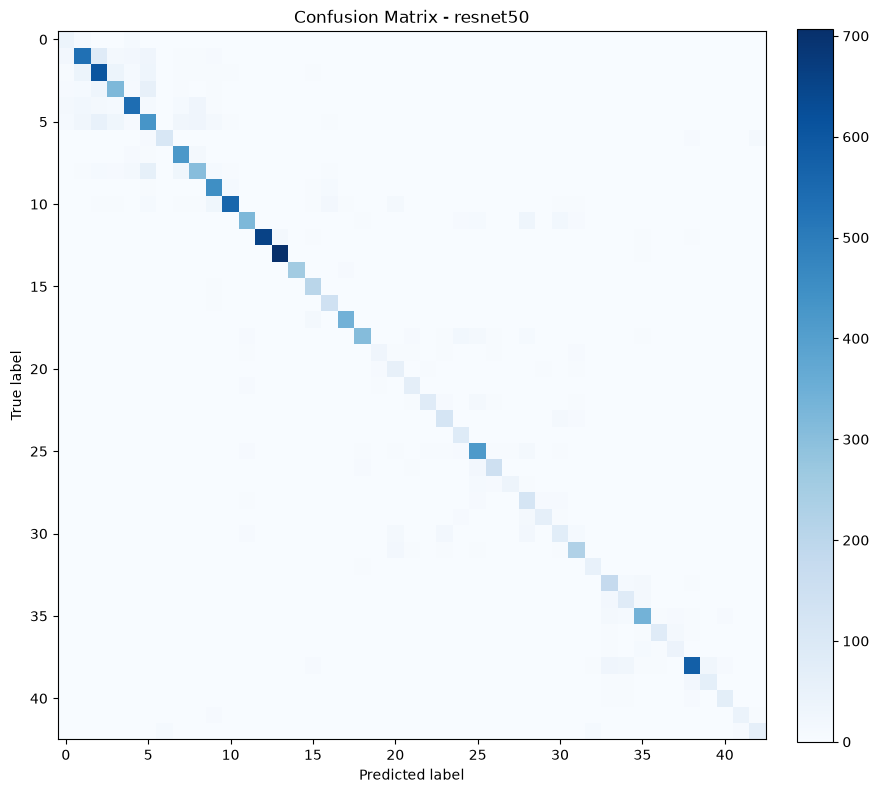

Saved confusion matrix to c:\Users\Mohammed Elidrissi\Desktop\traffic-sign-recognition-using-CNN\results_improved-v3\confusion_matrix_resnet50.png

--- vgg16 ---
Accuracy:  0.8120
Precision: 0.7902
Recall:    0.7664
F1-score:  0.7716


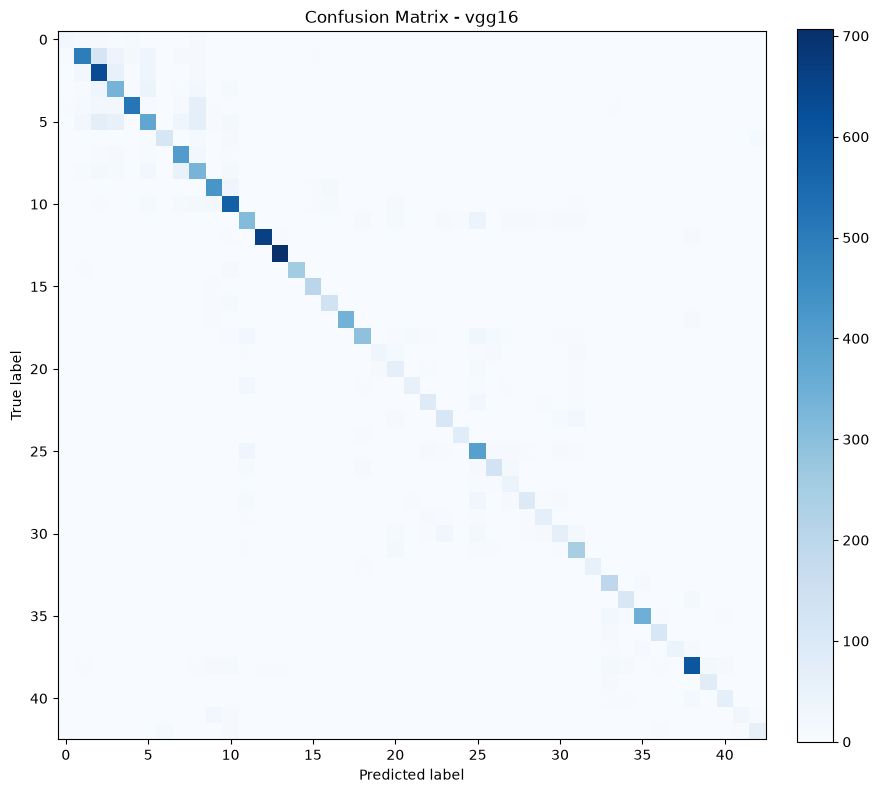

Saved confusion matrix to c:\Users\Mohammed Elidrissi\Desktop\traffic-sign-recognition-using-CNN\results_improved-v3\confusion_matrix_vgg16.png

--- efficientnet_b0 ---
Accuracy:  0.9374
Precision: 0.9239
Recall:    0.9251
F1-score:  0.9230


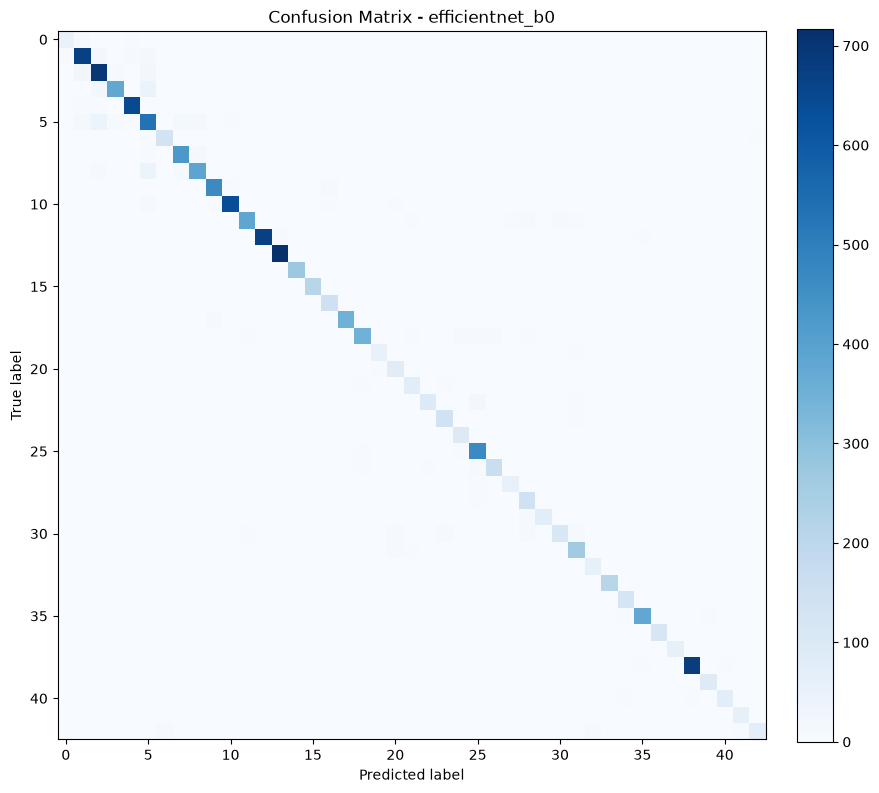

Saved confusion matrix to c:\Users\Mohammed Elidrissi\Desktop\traffic-sign-recognition-using-CNN\results_improved-v3\confusion_matrix_efficientnet_b0.png

--- HIICNN_stacking_ensemble ---
Accuracy:  0.9371
Precision: 0.9307
Recall:    0.9170
F1-score:  0.9212


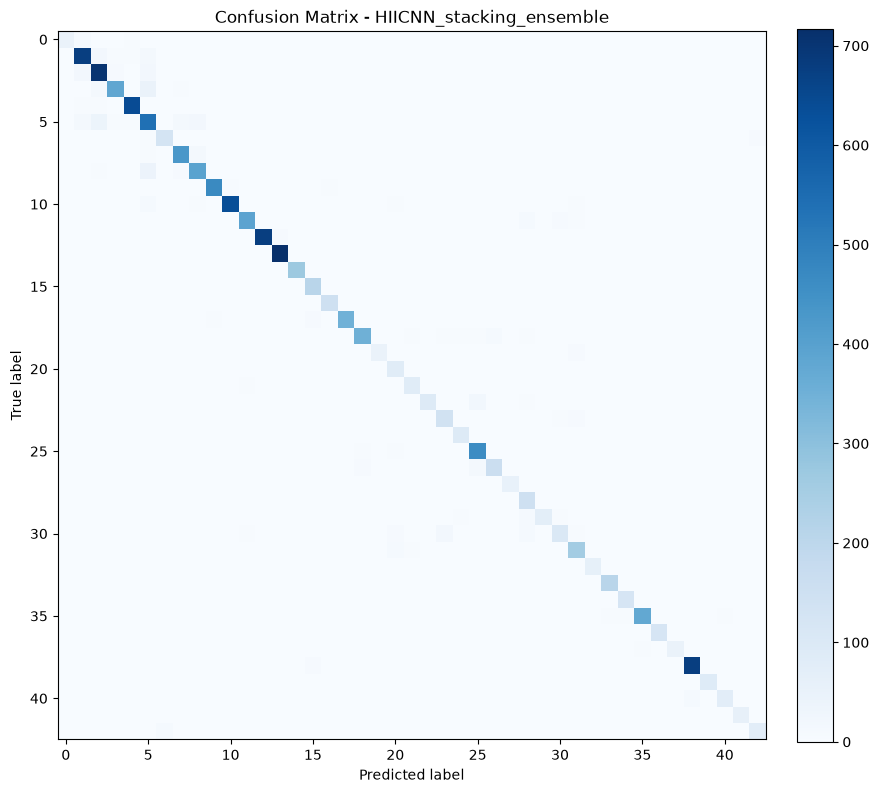

Saved confusion matrix to c:\Users\Mohammed Elidrissi\Desktop\traffic-sign-recognition-using-CNN\results_improved-v3\confusion_matrix_HIICNN_stacking_ensemble.png

--- naive_average_ensemble ---
Accuracy:  0.9332
Precision: 0.9222
Recall:    0.9183
F1-score:  0.9187

--- HIICNN_fast_ensemble_2backbone ---
Accuracy:  0.8587
Precision: 0.8352
Recall:    0.8191
F1-score:  0.8229


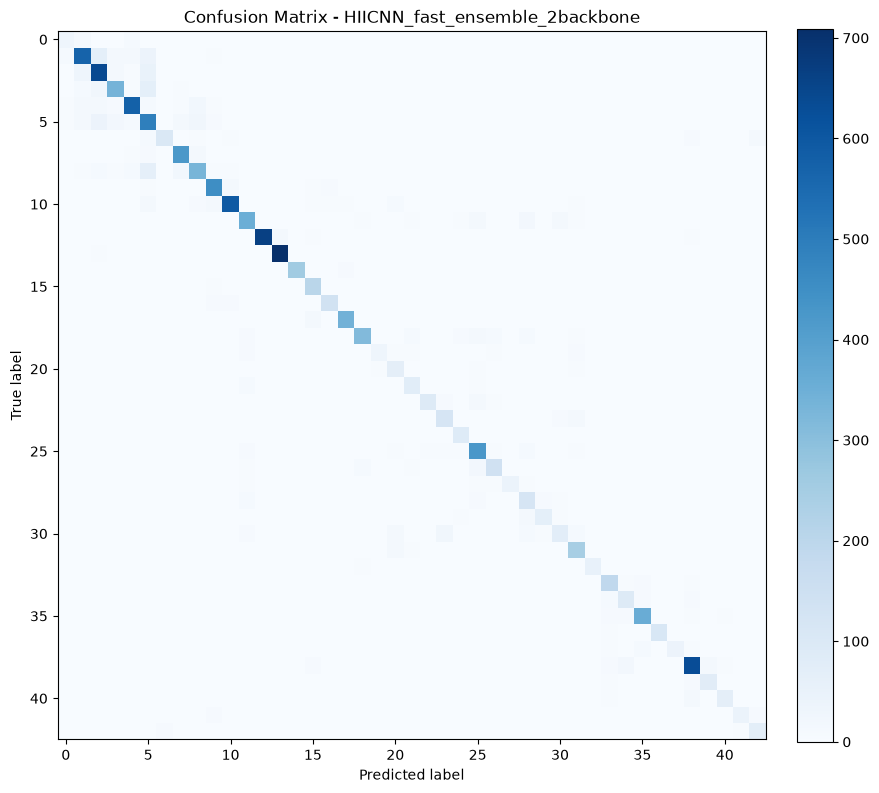

Saved confusion matrix to c:\Users\Mohammed Elidrissi\Desktop\traffic-sign-recognition-using-CNN\results_improved-v3\confusion_matrix_HIICNN_fast_ensemble_2backbone.png

Comparison table saved to c:\Users\Mohammed Elidrissi\Desktop\traffic-sign-recognition-using-CNN\results_improved-v3\comparison_table.json

Model                              Accuracy  Precision     Recall         F1
resnet50                             0.8202     0.7712     0.7813     0.7708
vgg16                                0.8120     0.7902     0.7664     0.7716
efficientnet_b0                      0.9374     0.9239     0.9251     0.9230
HIICNN_stacking_ensemble             0.9371     0.9307     0.9170     0.9212
naive_average_ensemble               0.9332     0.9222     0.9183     0.9187
HIICNN_fast_ensemble_2backbone       0.8587     0.8352     0.8191     0.8229


In [ ]:
all_results = []
backbone_probs = {}
y_true = None

for _name in BACKBONES:
    _model = load_trained_backbone(_name)
    probs, labels = get_softmax_predictions(_model, test_loader)
    backbone_probs[_name] = probs
    y_true = labels
    y_pred = probs.argmax(axis=1)
    all_results.append(compute_metrics(y_true, y_pred, _name))
    plot_confusion_matrix(y_true, y_pred, _name)

# HIICNN stacking ensemble (trained meta-learner, all 3 backbones)
stacked = np.concatenate([backbone_probs[_name] for _name in BACKBONES], axis=1)
meta = load_meta_learner(num_backbones=len(BACKBONES), filename="meta_learner.pt")
with torch.no_grad():
    X = torch.tensor(stacked, dtype=torch.float32).to(DEVICE)
    y_pred_ensemble = meta(X).argmax(1).cpu().numpy()

all_results.append(compute_metrics(y_true, y_pred_ensemble, "HIICNN_stacking_ensemble"))
plot_confusion_matrix(y_true, y_pred_ensemble, "HIICNN_stacking_ensemble")

# Naive-average ensemble (all 3), reported as a baseline the stacking
# meta-learner should beat
avg_probs = np.mean([backbone_probs[_name] for _name in BACKBONES], axis=0)
y_pred_avg = avg_probs.argmax(axis=1)
all_results.append(compute_metrics(y_true, y_pred_avg, "naive_average_ensemble"))

# --- Fast 2-backbone ensemble (drop EfficientNet-B0) -----------------------
fast_stacked = np.concatenate([backbone_probs[_name] for _name in FAST_ENSEMBLE_BACKBONES], axis=1)
fast_meta = load_meta_learner(num_backbones=len(FAST_ENSEMBLE_BACKBONES), filename="meta_learner_fast.pt")
with torch.no_grad():
    X_fast = torch.tensor(fast_stacked, dtype=torch.float32).to(DEVICE)
    y_pred_fast = fast_meta(X_fast).argmax(1).cpu().numpy()
all_results.append(compute_metrics(y_true, y_pred_fast, "HIICNN_fast_ensemble_2backbone"))
plot_confusion_matrix(y_true, y_pred_fast, "HIICNN_fast_ensemble_2backbone")

results_path = os.path.join(RESULTS_DIR, "comparison_table.json")
with open(results_path, "w") as f:
    json.dump(all_results, f, indent=2)
print(f"\nComparison table saved to {results_path}")

print("\n{:<32} {:>10} {:>10} {:>10} {:>10}".format("Model", "Accuracy", "Precision", "Recall", "F1"))
for r in all_results:
    print("{:<32} {:>10.4f} {:>10.4f} {:>10.4f} {:>10.4f}".format(
        r["model"], r["accuracy"], r["precision"], r["recall"], r["f1"]))


## 6. Real-time framing — inference latency (ms/image) and FPS


In [13]:
@torch.no_grad()
def benchmark_model(model, input_shape, n_warmup=20, n_runs=200, batch_size=1, use_amp_inference=USE_AMP_INFERENCE):
    """Real-time lever #1: fp16 autocast inference. This is a pure inference
    optimization — no retraining, no accuracy-relevant weight change — and
    is the cheapest of the "close the real-time gap" options the README's
    Future Work section lists, so it's applied here before anything else."""
    model.eval()
    dummy = torch.randn(batch_size, *input_shape).to(DEVICE)

    def _run():
        with torch.autocast(device_type=DEVICE.type, enabled=use_amp_inference):
            return model(dummy)

    for _ in range(n_warmup):
        _ = _run()
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()
    for _ in range(n_runs):
        _ = _run()
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    ms_per_image = (elapsed / n_runs / batch_size) * 1000
    fps = 1000 / ms_per_image
    return ms_per_image, fps


class EnsembleWrapper(nn.Module):
    """Wraps a set of backbones + their meta-learner into a single forward
    pass, so the whole HIICNN pipeline's latency can be measured
    end-to-end, the way it would run in a deployed system. Takes an
    arbitrary backbone list so the full 3-model and fast 2-model ensembles
    can both be benchmarked with the same code."""

    def __init__(self, backbones, meta):
        super().__init__()
        self.backbones = nn.ModuleList(backbones)
        self.meta = meta

    def forward(self, x):
        probs = [torch.softmax(b(x), dim=1) for b in self.backbones]
        stacked = torch.cat(probs, dim=1)
        return self.meta(stacked)


## Run: benchmark latency and FPS


In [ ]:
if DEVICE.type != "cuda":
    print("WARNING: no CUDA GPU detected — these numbers won't reflect the "
          "real-time GPU-inference framing.")

input_shape = (3, IMAGE_SIZE, IMAGE_SIZE)
bench_results = []
loaded_backbones = {}

for _name in BACKBONES:
    _model = load_trained_backbone(_name, required=False)
    loaded_backbones[_name] = _model
    ms, fps = benchmark_model(_model, input_shape, use_amp_inference=USE_AMP_INFERENCE)
    print(f"{_name:>18}: {ms:6.2f} ms/image  |  {fps:7.1f} FPS  (fp16={USE_AMP_INFERENCE})")
    bench_results.append({"model": _name, "ms_per_image": ms, "fps": fps, "fp16": USE_AMP_INFERENCE})

# --- Full 3-backbone ensemble, fp32 vs fp16 ---------------------------------
_meta = load_meta_learner(required=False, num_backbones=len(BACKBONES), filename="meta_learner.pt")
_ensemble_full = EnsembleWrapper([loaded_backbones[n] for n in BACKBONES], _meta).to(DEVICE)

ms_fp32, fps_fp32 = benchmark_model(_ensemble_full, input_shape, use_amp_inference=False)
print(f"{'HIICNN full (fp32)':>22}: {ms_fp32:6.2f} ms/image  |  {fps_fp32:7.1f} FPS")
bench_results.append({"model": "HIICNN_full_ensemble_fp32", "ms_per_image": ms_fp32, "fps": fps_fp32, "fp16": False})

ms_fp16, fps_fp16 = benchmark_model(_ensemble_full, input_shape, use_amp_inference=True)
print(f"{'HIICNN full (fp16)':>22}: {ms_fp16:6.2f} ms/image  |  {fps_fp16:7.1f} FPS")
bench_results.append({"model": "HIICNN_full_ensemble_fp16", "ms_per_image": ms_fp16, "fps": fps_fp16, "fp16": True})

# --- Fast 2-backbone ensemble (drop EfficientNet-B0), fp32 vs fp16 ----------
_fast_meta = load_meta_learner(required=False, num_backbones=len(FAST_ENSEMBLE_BACKBONES), filename="meta_learner_fast.pt")
_ensemble_fast = EnsembleWrapper([loaded_backbones[n] for n in FAST_ENSEMBLE_BACKBONES], _fast_meta).to(DEVICE)

ms_fast32, fps_fast32 = benchmark_model(_ensemble_fast, input_shape, use_amp_inference=False)
print(f"{'HIICNN fast (fp32)':>22}: {ms_fast32:6.2f} ms/image  |  {fps_fast32:7.1f} FPS")
bench_results.append({"model": "HIICNN_fast_ensemble_fp32", "ms_per_image": ms_fast32, "fps": fps_fast32, "fp16": False})

ms_fast16, fps_fast16 = benchmark_model(_ensemble_fast, input_shape, use_amp_inference=True)
print(f"{'HIICNN fast (fp16)':>22}: {ms_fast16:6.2f} ms/image  |  {fps_fast16:7.1f} FPS")
bench_results.append({"model": "HIICNN_fast_ensemble_fp16", "ms_per_image": ms_fast16, "fps": fps_fast16, "fp16": True})

print(f"\n{'='*70}\nReal-time target is >= 30 FPS. See comparison_table.json (previous "
      f"cell) for the accuracy each of these ensembles actually delivers — \n"
      f"the fast/fp16 combination is only worth shipping if that accuracy "
      f"cost is acceptable for the deployment target.\n{'='*70}")

bench_path = os.path.join(RESULTS_DIR, "latency_benchmark.json")
with open(bench_path, "w") as f:
    json.dump(bench_results, f, indent=2)
print(f"\nSaved benchmark results to {bench_path}")


          resnet50:  19.27 ms/image  |     51.9 FPS  (fp16=True)
             vgg16:   4.32 ms/image  |    231.5 FPS  (fp16=True)
   efficientnet_b0:  15.07 ms/image  |     66.3 FPS  (fp16=True)
    HIICNN full (fp32):  10.11 ms/image  |     98.9 FPS
    HIICNN full (fp16):  13.14 ms/image  |     76.1 FPS
    HIICNN fast (fp32):   5.01 ms/image  |    199.8 FPS
    HIICNN fast (fp16):   6.40 ms/image  |    156.2 FPS

Real-time target is >= 30 FPS. See comparison_table.json (previous cell) for the accuracy each of these ensembles actually delivers — 
the fast/fp16 combination is only worth shipping if that accuracy cost is acceptable for the deployment target.

Saved benchmark results to c:\Users\Mohammed Elidrissi\Desktop\traffic-sign-recognition-using-CNN\results_improved-v3\latency_benchmark.json


: 